# Lecture 08 — Unsupervised Learning I: Clustering

**Learning objectives**

- State the $k$-means objective, derive Lloyd's algorithm as coordinate descent, and implement it (with $k$-means++ initialisation) from scratch.
- Choose the number of clusters with the elbow method and silhouette analysis, and recognise the failure modes of $k$-means.
- Derive the EM algorithm for Gaussian Mixture Models (E-step responsibilities, M-step updates), implement it from scratch, and compare with `sklearn.mixture.GaussianMixture`.
- Select GMM complexity with BIC/AIC.
- Use hierarchical (agglomerative) clustering with dendrograms and density-based clustering (DBSCAN).
- Evaluate clusterings with external (ARI, NMI) and internal (silhouette) measures, and cluster a real data set (`load_digits`).

**Prerequisites**

- Linear algebra and multivariate Gaussians; maximum likelihood estimation ([`01_mathematical_foundations.ipynb`](01_mathematical_foundations.ipynb), [`05_knn_and_naive_bayes.ipynb`](05_knn_and_naive_bayes.ipynb) for Gaussian generative models).
- Lecture 07 ([`07_decision_trees_and_ensembles.ipynb`](07_decision_trees_and_ensembles.ipynb)) is not required; the following lecture, [`09_dimensionality_reduction.ipynb`](09_dimensionality_reduction.ipynb), builds on this one.

**Contents**

1. What is clustering?
2. $k$-means: objective and Lloyd's algorithm
3. $k$-means++ initialisation
4. Choosing $k$: elbow and silhouette
5. Limitations of $k$-means
6. Gaussian Mixture Models and EM
7. Model selection with BIC/AIC
8. Hierarchical clustering and dendrograms
9. DBSCAN
10. Evaluating clusterings; clustering handwritten digits
11. Pitfalls & practical tips
12. Exercises
13. Summary and further reading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.datasets import make_blobs, make_moons, load_digits, load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples, adjusted_rand_score,
                             normalized_mutual_info_score, confusion_matrix)
from matplotlib.patches import Ellipse

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)
np.random.seed(42)
rng = np.random.default_rng(42)

## 1. What is clustering?

Given unlabeled data $\{\mathbf x_1,\dots,\mathbf x_n\}\subset\mathbb R^d$, clustering seeks a partition (or soft assignment) such that points in the same group are "similar" and points in different groups are "dissimilar". Unlike supervised learning there is **no ground truth**: different algorithms encode different notions of a cluster.

| family | notion of cluster | examples |
|---|---|---|
| centroid-based | points close to a prototype | $k$-means, $k$-medoids |
| model-based | points generated by the same distribution | Gaussian mixtures (EM) |
| hierarchical | nested groups at all scales | agglomerative (single/complete/average/Ward) |
| density-based | high-density regions separated by low density | DBSCAN, HDBSCAN, mean shift |
| graph-based | weakly connected components of a similarity graph | spectral clustering |

Kleinberg's *impossibility theorem* (2002) formalises the ambiguity: no clustering function simultaneously satisfies scale-invariance, richness and consistency. The choice of algorithm is a modelling decision.

## 2. $k$-means: objective and Lloyd's algorithm

$k$-means seeks $k$ centroids $\boldsymbol\mu_1,\dots,\boldsymbol\mu_k$ and assignments $z_i\in\{1,\dots,k\}$ that minimise the **within-cluster sum of squares** (WCSS, "inertia"):
$$
J(\mathbf z, \boldsymbol\mu) = \sum_{i=1}^n\lVert\mathbf x_i-\boldsymbol\mu_{z_i}\rVert^2 = \sum_{j=1}^k\sum_{i:z_i=j}\lVert\mathbf x_i-\boldsymbol\mu_j\rVert^2 .
$$
Finding the global minimum is NP-hard (even for $k=2$ in general $d$). **Lloyd's algorithm** performs **block coordinate descent**:

- **Assignment step** (fix $\boldsymbol\mu$, minimise over $\mathbf z$): each term is independent, so $z_i = \arg\min_j\lVert\mathbf x_i-\boldsymbol\mu_j\rVert^2$ — assign to the nearest centroid. This partitions space into a **Voronoi diagram**.
- **Update step** (fix $\mathbf z$, minimise over $\boldsymbol\mu$): $\nabla_{\boldsymbol\mu_j}J = -2\sum_{i:z_i=j}(\mathbf x_i-\boldsymbol\mu_j)=0\Rightarrow\boldsymbol\mu_j=\frac{1}{n_j}\sum_{i:z_i=j}\mathbf x_i$ — the cluster mean.

Neither step can increase $J$, and there are finitely many partitions, so the algorithm **converges in finitely many steps** — but only to a *local* minimum, which depends on initialisation. Each iteration costs $O(nkd)$.

Useful identity: $\sum_{i\in C}\lVert\mathbf x_i-\bar{\mathbf x}_C\rVert^2 = \frac{1}{2|C|}\sum_{i,i'\in C}\lVert\mathbf x_i-\mathbf x_{i'}\rVert^2$, so $k$-means equivalently minimises average within-cluster pairwise squared distances.

In [2]:
def kmeans_pp_init(X, k, rng):
    # k-means++ seeding: next centre sampled with probability proportional to D(x)^2
    n = len(X)
    centers = [X[rng.integers(n)]]
    d2 = ((X - centers[0]) ** 2).sum(1)
    for _ in range(1, k):
        idx = rng.choice(n, p=d2 / d2.sum())
        centers.append(X[idx])
        d2 = np.minimum(d2, ((X - X[idx]) ** 2).sum(1))   # distance to nearest chosen centre
    return np.array(centers)

def kmeans_scratch(X, k, init="k-means++", n_init=10, max_iter=300, tol=1e-6, seed=0):
    # Lloyd's algorithm with multiple restarts; returns the best (lowest-inertia) run.
    rng = np.random.default_rng(seed)
    best = None
    for run in range(n_init):
        if init == "k-means++":
            C = kmeans_pp_init(X, k, rng)
        else:                                            # "random": k distinct data points
            C = X[rng.choice(len(X), k, replace=False)]
        history = []
        for it in range(max_iter):
            # assignment step: squared distances to all centres, shape (n, k)
            D = ((X[:, None, :] - C[None, :, :]) ** 2).sum(-1)
            z = D.argmin(1)
            history.append(D[np.arange(len(X)), z].sum())
            # update step: centroid = mean of assigned points (keep old centre if cluster empty)
            C_new = np.array([X[z == j].mean(0) if np.any(z == j) else C[j] for j in range(k)])
            shift = ((C_new - C) ** 2).sum()
            C = C_new
            if shift < tol:
                break
        D = ((X[:, None, :] - C[None, :, :]) ** 2).sum(-1)
        z = D.argmin(1); inertia = D[np.arange(len(X)), z].sum()
        if best is None or inertia < best["inertia"]:
            best = dict(centers=C, labels=z, inertia=inertia, n_iter=it + 1, history=history)
    return best

inertia  scratch = 986.30   sklearn = 986.30
ARI between scratch and sklearn labelings = 1.000


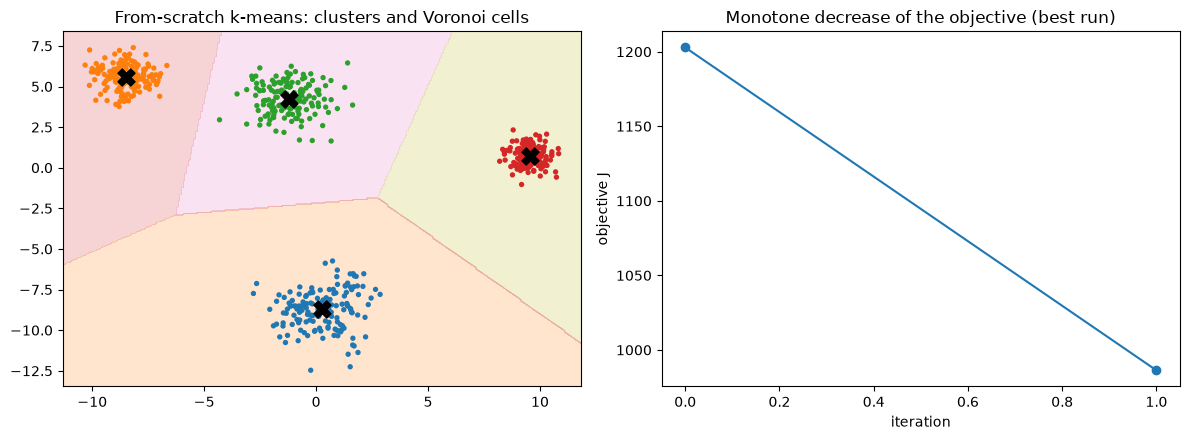

In [3]:
X, y_true = make_blobs(n_samples=600, centers=4, cluster_std=[0.8, 1.0, 0.6, 1.2], random_state=7)
ours = kmeans_scratch(X, 4, seed=0)
sk = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)
print(f"inertia  scratch = {ours['inertia']:.2f}   sklearn = {sk.inertia_:.2f}")
print(f"ARI between scratch and sklearn labelings = {adjusted_rand_score(ours['labels'], sk.labels_):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Voronoi regions of the learned centroids
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = ((grid[:, None, :] - ours["centers"][None]) ** 2).sum(-1).argmin(1).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.2, cmap="tab10", levels=np.arange(-0.5, 4))
axes[0].scatter(X[:, 0], X[:, 1], c=ours["labels"], cmap="tab10", s=8, vmin=0, vmax=9)
axes[0].scatter(*ours["centers"].T, c="k", marker="X", s=150)
axes[0].set_title("From-scratch k-means: clusters and Voronoi cells")
axes[1].plot(ours["history"], "o-"); axes[1].set_xlabel("iteration"); axes[1].set_ylabel("objective J")
axes[1].set_title("Monotone decrease of the objective (best run)")
plt.tight_layout(); plt.show()

## 3. $k$-means++ initialisation

Random initialisation can place several centroids in the same true cluster, leaving Lloyd stuck in a poor local minimum. **$k$-means++** (Arthur & Vassilvitskii, 2007) picks the first centre uniformly at random, and each subsequent centre with probability
$$
P(\mathbf x_i) = \frac{D(\mathbf x_i)^2}{\sum_{i'}D(\mathbf x_{i'})^2},
$$
where $D(\mathbf x)$ is the distance to the nearest centre chosen so far. This spreads centres out, and gives a provable guarantee: $\mathbb E[J_{\text{init}}]\le 8(\ln k+2)\,J^\*$ — i.e. an $O(\log k)$-approximation *before* running Lloyd at all.

We compare random vs. $k$-means++ initialisation over many single runs on a data set with 10 well-separated clusters.

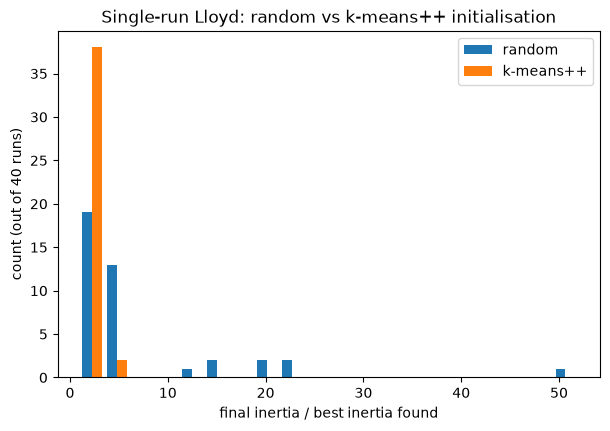

random    : fraction of runs within 1% of best = 0.05
k-means++ : fraction of runs within 1% of best = 0.23


In [4]:
X10, y10 = make_blobs(n_samples=1000, centers=10, cluster_std=0.5, center_box=(-15, 15), random_state=3)
res = {"random": [], "k-means++": []}
for s in range(40):
    for init in res:
        res[init].append(kmeans_scratch(X10, 10, init=init, n_init=1, seed=s)["inertia"])
opt = min(min(v) for v in res.values())
plt.hist([np.array(res["random"]) / opt, np.array(res["k-means++"]) / opt], bins=20, label=list(res))
plt.xlabel("final inertia / best inertia found"); plt.ylabel("count (out of 40 runs)")
plt.title("Single-run Lloyd: random vs k-means++ initialisation"); plt.legend(); plt.show()
for k_, v in res.items():
    print(f"{k_:10s}: fraction of runs within 1% of best = {np.mean(np.array(v) / opt < 1.01):.2f}")

## 4. Choosing $k$: elbow and silhouette

$J$ always decreases with $k$ (with $k=n$, $J=0$), so we cannot minimise it over $k$.

- **Elbow method:** plot $J(k)$ and look for the point where the decrease slows down sharply. Often ambiguous.
- **Silhouette:** for point $i$ in cluster $C$, let $a(i)$ be the mean distance to other points in $C$ and $b(i)=\min_{C'\ne C}$ mean distance to points in $C'$ (the nearest other cluster). Then
$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}\in[-1,1].
$$
$s(i)\approx1$: well clustered; $\approx0$: on a border; $<0$: probably misassigned. The mean silhouette over all points is a model-selection criterion (cost $O(n^2)$).
- Other options: the **gap statistic** (Tibshirani et al., 2001), which compares $\log J(k)$ against its expectation under a uniform reference distribution; and, for GMMs, **BIC** (Section 7).

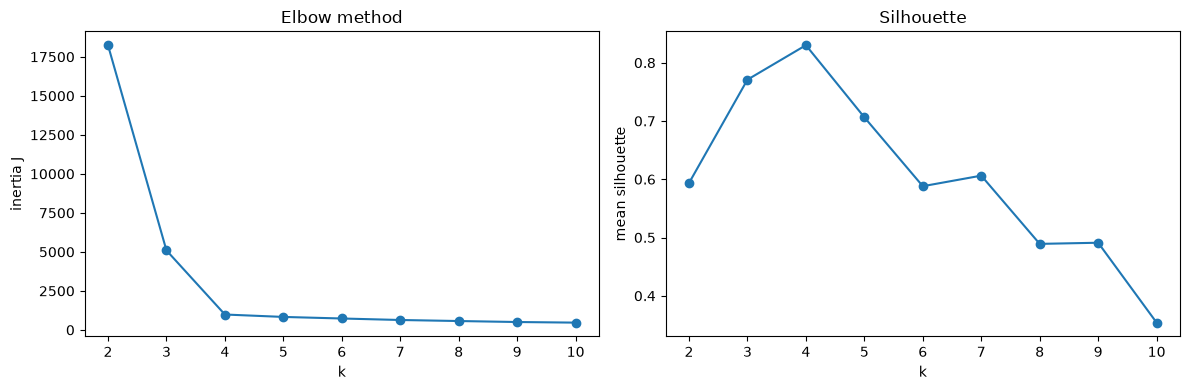

k maximising the silhouette: 4 (true number of blobs = 4)


In [5]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertias, "o-"); axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia J"); axes[0].set_title("Elbow method")
axes[1].plot(list(ks), sils, "o-"); axes[1].set_xlabel("k"); axes[1].set_ylabel("mean silhouette"); axes[1].set_title("Silhouette")
plt.tight_layout(); plt.show()
print("k maximising the silhouette:", list(ks)[int(np.argmax(sils))], "(true number of blobs = 4)")

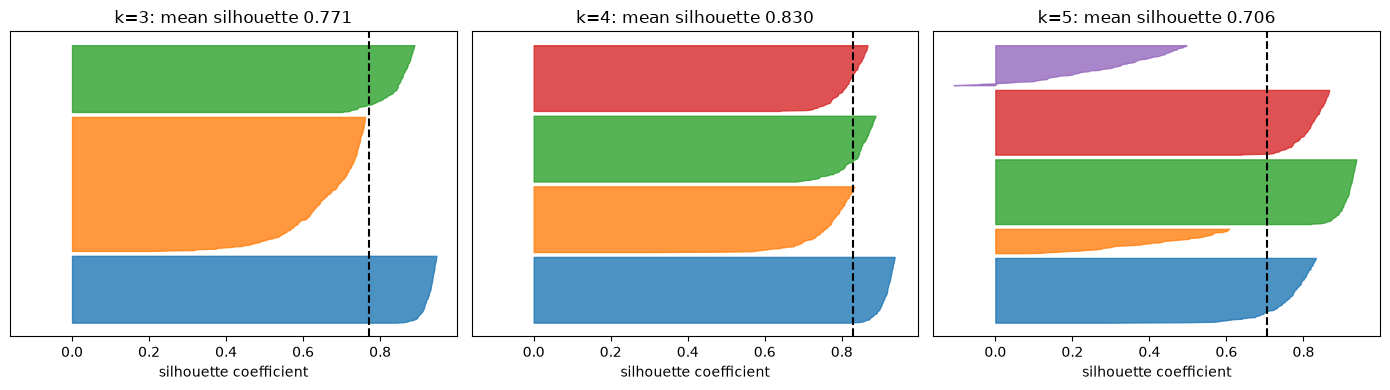

In [6]:
# Silhouette plots: per-sample silhouettes for k = 3, 4, 5
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
for ax, k in zip(axes, [3, 4, 5]):
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)
    s = silhouette_samples(X, labels)
    y0 = 0
    for j in range(k):
        sj = np.sort(s[labels == j])
        ax.fill_betweenx(np.arange(y0, y0 + len(sj)), 0, sj, color=plt.cm.tab10(j), alpha=0.8)
        y0 += len(sj) + 10
    ax.axvline(s.mean(), color="k", ls="--"); ax.set_yticks([])
    ax.set_title(f"k={k}: mean silhouette {s.mean():.3f}"); ax.set_xlabel("silhouette coefficient")
plt.tight_layout(); plt.show()

## 5. Limitations of $k$-means

$k$-means implicitly assumes clusters that are **convex, isotropic (spherical), of similar size/variance**, since it assigns by Euclidean distance to a centroid. It is a limiting case of a GMM with shared covariance $\sigma^2I$ and $\sigma\to0$ (Section 6). Consequences:

- **Non-convex shapes** (moons, rings) cannot be represented.
- **Anisotropic** (elongated, correlated) clusters are cut across their long axis.
- **Unequal variances / sizes**: boundaries sit halfway between centroids, so large clusters "donate" points to small neighbouring ones.
- **Scale-dependence**: features must be on comparable scales.
- Sensitive to outliers (the mean is not robust); $k$-medoids is a robust alternative.

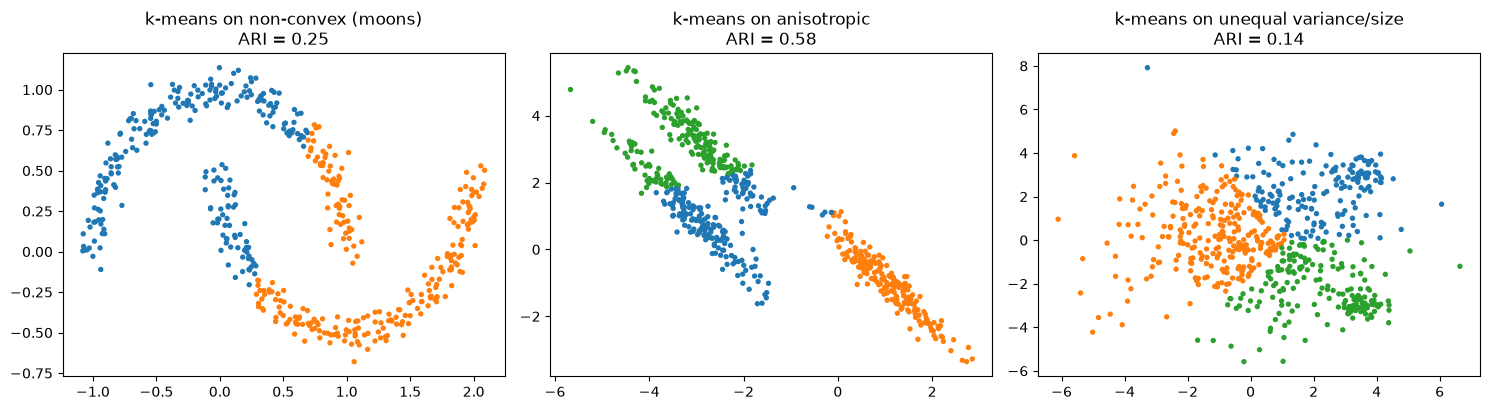

In [7]:
Xm, ym = make_moons(n_samples=500, noise=0.06, random_state=0)
Xa, ya = make_blobs(n_samples=600, centers=3, random_state=170)
Xa = Xa @ np.array([[0.6, -0.64], [-0.41, 0.85]])                 # anisotropic linear transform
Xv, yv = make_blobs(n_samples=[500, 60, 60], centers=[[0, 0], [3.5, 3], [3.5, -3]],
                    cluster_std=[2.0, 0.4, 0.4], random_state=1)    # unequal variance and size

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (Xd, yd, k, title) in zip(axes, [(Xm, ym, 2, "non-convex (moons)"), (Xa, ya, 3, "anisotropic"),
                                         (Xv, yv, 3, "unequal variance/size")]):
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xd)
    ax.scatter(Xd[:, 0], Xd[:, 1], c=lab, cmap="tab10", s=8, vmin=0, vmax=9)
    ax.set_title(f"k-means on {title}\nARI = {adjusted_rand_score(yd, lab):.2f}")
plt.tight_layout(); plt.show()

## 6. Gaussian Mixture Models and EM

### 6.1 The model

A GMM is the generative model
$$
z_i\sim\operatorname{Cat}(\boldsymbol\pi),\qquad \mathbf x_i\mid z_i=j\sim\mathcal N(\boldsymbol\mu_j,\boldsymbol\Sigma_j),
\qquad\Rightarrow\qquad p(\mathbf x)=\sum_{j=1}^k\pi_j\,\mathcal N(\mathbf x\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j).
$$
With full covariances it can model elongated, rotated clusters of different sizes, and gives **soft assignments** $p(z_i=j\mid\mathbf x_i)$.

The log-likelihood $\ell(\theta)=\sum_i\log\sum_j\pi_j\mathcal N(\mathbf x_i\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)$ has a sum inside the log, so there is no closed-form MLE. (It is also unbounded: a component collapsing onto a single point with $\boldsymbol\Sigma_j\to0$ sends $\ell\to\infty$ — hence covariance regularisation in practice.)

### 6.2 EM derivation

For any distribution $q_i(z)$ over the latent variable, Jensen's inequality gives the **evidence lower bound**
$$
\log p(\mathbf x_i\mid\theta)=\log\sum_jq_i(j)\frac{p(\mathbf x_i,z=j\mid\theta)}{q_i(j)}\;\ge\;\sum_jq_i(j)\log\frac{p(\mathbf x_i,z=j\mid\theta)}{q_i(j)} =: \mathcal L_i(q_i,\theta),
$$
with gap $\log p(\mathbf x_i\mid\theta)-\mathcal L_i = \mathrm{KL}\big(q_i\,\|\,p(z\mid\mathbf x_i,\theta)\big)\ge0$. EM is coordinate ascent on $\mathcal L=\sum_i\mathcal L_i$:

**E-step** (maximise over $q$, closing the gap): $q_i(j)=p(z_i=j\mid\mathbf x_i,\theta)$, i.e. the **responsibilities**
$$
r_{ij}=\frac{\pi_j\,\mathcal N(\mathbf x_i\mid\boldsymbol\mu_j,\boldsymbol\Sigma_j)}{\sum_{l}\pi_l\,\mathcal N(\mathbf x_i\mid\boldsymbol\mu_l,\boldsymbol\Sigma_l)} .
$$

**M-step** (maximise over $\theta$ with $r$ fixed): maximise the expected complete-data log-likelihood
$$
Q(\theta)=\sum_i\sum_jr_{ij}\Big[\log\pi_j-\tfrac12\log|2\pi\boldsymbol\Sigma_j|-\tfrac12(\mathbf x_i-\boldsymbol\mu_j)^\top\boldsymbol\Sigma_j^{-1}(\mathbf x_i-\boldsymbol\mu_j)\Big].
$$
Let $N_j=\sum_ir_{ij}$ (effective cluster size).

- $\partial Q/\partial\boldsymbol\mu_j=\sum_ir_{ij}\boldsymbol\Sigma_j^{-1}(\mathbf x_i-\boldsymbol\mu_j)=0\Rightarrow\boxed{\boldsymbol\mu_j=\frac1{N_j}\sum_ir_{ij}\mathbf x_i}$
- Using $\partial\log|\boldsymbol\Sigma|/\partial\boldsymbol\Sigma^{-1}=-\boldsymbol\Sigma$ and $\partial\,\mathbf a^\top\boldsymbol\Sigma^{-1}\mathbf a/\partial\boldsymbol\Sigma^{-1}=\mathbf a\mathbf a^\top$: $\boxed{\boldsymbol\Sigma_j=\frac1{N_j}\sum_ir_{ij}(\mathbf x_i-\boldsymbol\mu_j)(\mathbf x_i-\boldsymbol\mu_j)^\top}$
- With a Lagrange multiplier for $\sum_j\pi_j=1$: $\boxed{\pi_j=N_j/n}$

These are weighted versions of the single-Gaussian MLEs. Because each step increases $\mathcal L$ and the E-step makes the bound tight, **the log-likelihood never decreases**. EM converges to a local maximum (or saddle point); initialisation matters (sklearn initialises with $k$-means).

**Connection to $k$-means.** With $\boldsymbol\Sigma_j=\sigma^2I$ fixed, equal $\pi_j$, and $\sigma\to0$, the responsibilities become hard one-hot assignments to the nearest mean, and the M-step reduces to computing cluster means: $k$-means is "hard EM".

**Numerics.** Compute responsibilities in log space with the log-sum-exp trick, and add a small ridge $\epsilon I$ to each covariance.

In [8]:
class GMMScratch:
    # Full-covariance Gaussian mixture fitted by EM (from scratch).
    def __init__(self, k, max_iter=200, tol=1e-6, reg=1e-6, seed=0):
        self.k, self.max_iter, self.tol, self.reg, self.seed = k, max_iter, tol, reg, seed

    def _log_gauss(self, X):
        # log N(x_i | mu_j, Sigma_j) for all i, j via Cholesky; shape (n, k)
        n, d = X.shape
        out = np.empty((n, self.k))
        for j in range(self.k):
            L = np.linalg.cholesky(self.covs_[j])
            sol = np.linalg.solve(L, (X - self.means_[j]).T)        # L^{-1}(x - mu)
            maha = (sol ** 2).sum(0)                               # Mahalanobis distance squared
            logdet = 2 * np.log(np.diag(L)).sum()
            out[:, j] = -0.5 * (d * np.log(2 * np.pi) + logdet + maha)
        return out

    def _e_step(self, X):
        log_joint = self._log_gauss(X) + np.log(self.weights_)     # log pi_j + log N(x_i | .)
        log_px = logsumexp(log_joint, axis=1)                      # log p(x_i)
        return np.exp(log_joint - log_px[:, None]), log_px.sum()   # responsibilities, log-likelihood

    def _m_step(self, X, R):
        n, d = X.shape
        Nk = R.sum(0) + 1e-12                                      # effective counts
        self.weights_ = Nk / n
        self.means_ = (R.T @ X) / Nk[:, None]
        self.covs_ = np.empty((self.k, d, d))
        for j in range(self.k):
            Xc = X - self.means_[j]
            self.covs_[j] = (R[:, j, None] * Xc).T @ Xc / Nk[j] + self.reg * np.eye(d)

    def fit(self, X):
        n, d = X.shape
        # initialise from k-means (hard responsibilities), as sklearn does by default
        labels = KMeans(self.k, n_init=1, random_state=self.seed).fit_predict(X)
        self._m_step(X, np.eye(self.k)[labels])
        self.loglik_ = []
        for it in range(self.max_iter):
            R, ll = self._e_step(X)
            self.loglik_.append(ll)
            if it > 0 and abs(ll - self.loglik_[-2]) < self.tol * abs(ll):
                break
            self._m_step(X, R)
        return self

    def predict_proba(self, X):
        return self._e_step(X)[0]

    def predict(self, X):
        return self.predict_proba(X).argmax(1)

    def score(self, X):                                            # mean log-likelihood per sample
        return self._e_step(X)[1] / len(X)

mean log-likelihood  scratch = -2.49214   sklearn = -2.49214
ARI scratch vs truth = 1.000   sklearn vs truth = 1.000
weights scratch: [0.333 0.333 0.334]   sklearn: [0.333 0.333 0.334]


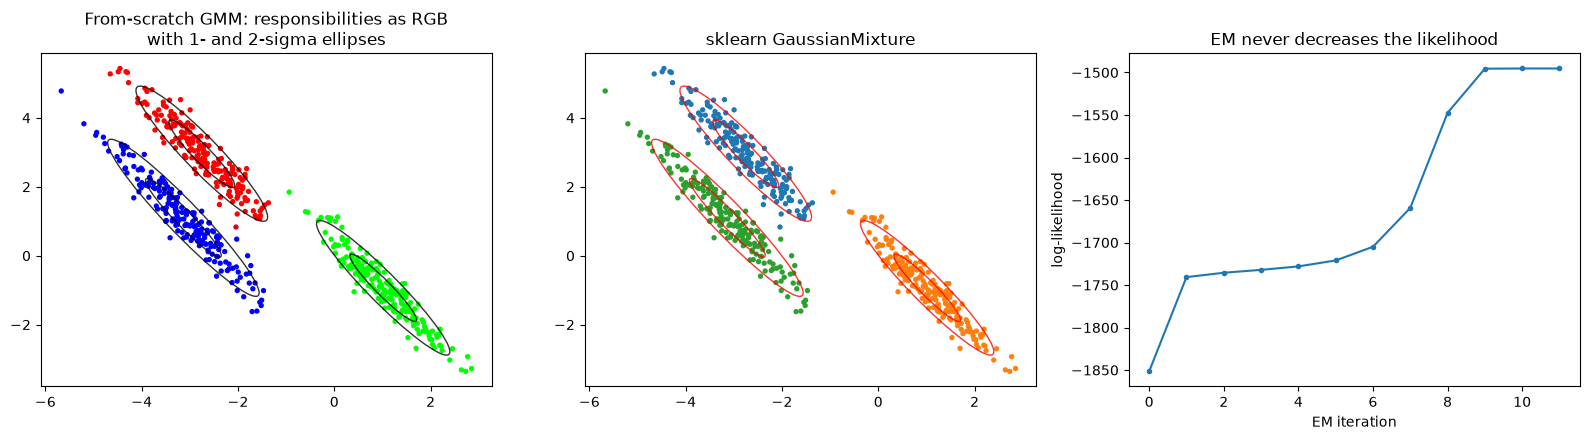

In [9]:
gmm_ours = GMMScratch(3, seed=0).fit(Xa)
gmm_sk = GaussianMixture(3, covariance_type="full", reg_covar=1e-6, tol=1e-8, max_iter=500, random_state=0).fit(Xa)
print(f"mean log-likelihood  scratch = {gmm_ours.score(Xa):.5f}   sklearn = {gmm_sk.score(Xa):.5f}")
print(f"ARI scratch vs truth = {adjusted_rand_score(ya, gmm_ours.predict(Xa)):.3f}   "
      f"sklearn vs truth = {adjusted_rand_score(ya, gmm_sk.predict(Xa)):.3f}")
order = np.argsort(gmm_ours.weights_); order_sk = np.argsort(gmm_sk.weights_)
print("weights scratch:", gmm_ours.weights_[order].round(3), "  sklearn:", gmm_sk.weights_[order_sk].round(3))

def draw_ellipses(ax, means, covs, color="k"):
    for mu, S in zip(means, covs):
        vals, vecs = np.linalg.eigh(S)
        angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
        for nsig in [1, 2]:
            w, h = 2 * nsig * np.sqrt(vals[::-1])
            ax.add_patch(Ellipse(mu, w, h, angle=angle, fill=False, color=color, lw=1, alpha=0.8))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
P = gmm_ours.predict_proba(Xa)
axes[0].scatter(Xa[:, 0], Xa[:, 1], c=P, s=8)                  # RGB colour = soft responsibilities
draw_ellipses(axes[0], gmm_ours.means_, gmm_ours.covs_)
axes[0].set_title("From-scratch GMM: responsibilities as RGB\nwith 1- and 2-sigma ellipses")
axes[1].scatter(Xa[:, 0], Xa[:, 1], c=gmm_sk.predict(Xa), cmap="tab10", s=8, vmin=0, vmax=9)
draw_ellipses(axes[1], gmm_sk.means_, gmm_sk.covariances_, color="r")
axes[1].set_title("sklearn GaussianMixture")
axes[2].plot(gmm_ours.loglik_, "o-", ms=3); axes[2].set_xlabel("EM iteration"); axes[2].set_ylabel("log-likelihood")
axes[2].set_title("EM never decreases the likelihood")
plt.tight_layout(); plt.show()

Where $k$-means failed on the anisotropic blobs (ARI $\approx0.58$), the full-covariance GMM recovers the clusters almost perfectly. The colour blends in the left panel show points with genuinely uncertain membership.

### 6.3 $k$-means as the hard, isotropic limit of EM

We check the connection numerically: run EM with fixed covariances $\sigma^2I$ and equal weights, updating only the means, and shrink $\sigma$. As $\sigma\to0$ the responsibilities become one-hot and the fitted means coincide with the $k$-means centroids.

In [10]:
def isotropic_em_means(X, k, sigma, n_iter=100, seed=0):
    # EM for a GMM with fixed Sigma_j = sigma^2 I and pi_j = 1/k; only the means are learned
    mu = KMeans(k, n_init=1, init="random", max_iter=1, random_state=seed).fit(X).cluster_centers_
    for _ in range(n_iter):
        logits = -((X[:, None, :] - mu[None]) ** 2).sum(-1) / (2 * sigma ** 2)
        R = np.exp(logits - logsumexp(logits, axis=1, keepdims=True))     # E-step
        mu = (R.T @ X) / R.sum(0)[:, None]                                 # M-step (means only)
    return mu, R

km4 = KMeans(4, n_init=10, random_state=0).fit(X)
for sigma in [3.0, 1.0, 0.3, 0.05]:
    mu, R = isotropic_em_means(X, 4, sigma)
    # match EM means to k-means centroids by nearest neighbour
    gap = np.sqrt(((mu[:, None] - km4.cluster_centers_[None]) ** 2).sum(-1)).min(1).max()
    print(f"sigma={sigma:4.2f}: mean max-responsibility = {R.max(1).mean():.3f}, "
          f"max distance to k-means centroid = {gap:.3f}")

sigma=3.00: mean max-responsibility = 0.960, max distance to k-means centroid = 0.527
sigma=1.00: mean max-responsibility = 1.000, max distance to k-means centroid = 0.000
sigma=0.30: mean max-responsibility = 1.000, max distance to k-means centroid = 0.000
sigma=0.05: mean max-responsibility = 1.000, max distance to k-means centroid = 0.000


### 6.4 A GMM is a generative model

Unlike $k$-means, a fitted GMM defines a density $p(\mathbf x)$, so we can **sample** new data and **score** points (low $p(\mathbf x)$ = anomaly). As a preview, we fit a 10-component GMM to digit images compressed to 30 principal components (PCA is the topic of Lecture 09), sample from it, and map the samples back to pixel space. Choosing the number of components for such a density model is itself a model-selection problem, discussed next.

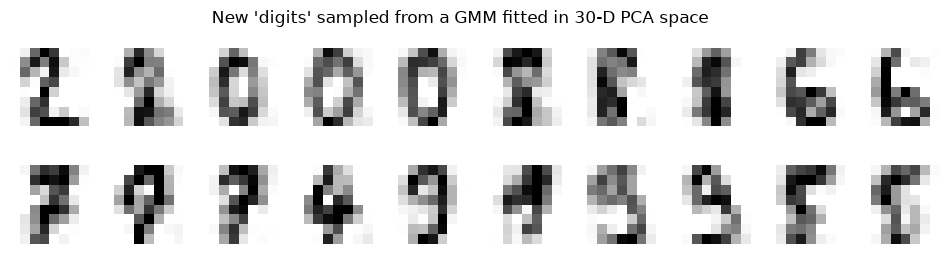

lowest-likelihood training images (candidate anomalies), true labels: [6 6 2 6 5 7 5 9 2 4]


In [11]:
digits_all = load_digits()
pca_gen = PCA(n_components=30, whiten=False, random_state=0).fit(digits_all.data)
Zg = pca_gen.transform(digits_all.data)
gmm_gen = GaussianMixture(n_components=10, covariance_type="full", random_state=0).fit(Zg)
samples, _ = gmm_gen.sample(20)
imgs = np.clip(pca_gen.inverse_transform(samples), 0, 16)
fig, axes = plt.subplots(2, 10, figsize=(12, 2.8))
for ax, im in zip(axes.ravel(), imgs):
    ax.imshow(im.reshape(8, 8), cmap="gray_r"); ax.axis("off")
fig.suptitle("New 'digits' sampled from a GMM fitted in 30-D PCA space"); plt.show()
ll = gmm_gen.score_samples(Zg)
print("lowest-likelihood training images (candidate anomalies), true labels:", digits_all.target[np.argsort(ll)[:10]])

## 7. Model selection with BIC/AIC

The likelihood increases with $k$, so we penalise the number of free parameters $p$. For a $d$-dimensional GMM with full covariances, $p = (k-1) + kd + k\frac{d(d+1)}{2}$.
$$
\mathrm{AIC}=-2\ell(\hat\theta)+2p,\qquad \mathrm{BIC}=-2\ell(\hat\theta)+p\log n .
$$
BIC approximates $-2\log p(\text{data}\mid\text{model})$ (Laplace approximation of the marginal likelihood) and is consistent for selecting the true $k$ as $n\to\infty$; AIC targets predictive accuracy and tends to select more components. Lower is better. We can also compare **covariance structures**: `full`, `tied` (shared $\boldsymbol\Sigma$), `diag`, `spherical`.

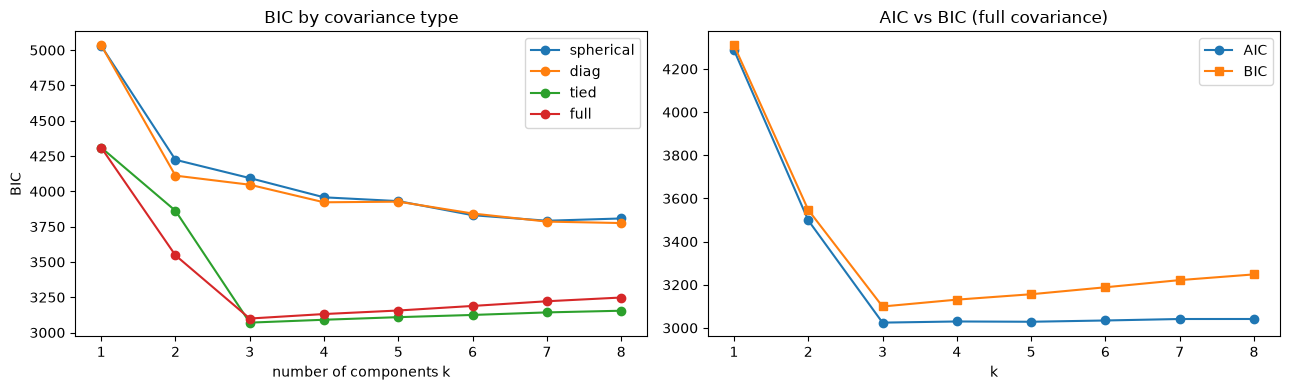

BIC manual == sklearn: True | best k by BIC: 3 | best k by AIC: 3


In [12]:
def n_params_full(k, d):
    return (k - 1) + k * d + k * d * (d + 1) // 2

ks = range(1, 9)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ct in ["spherical", "diag", "tied", "full"]:
    bics = [GaussianMixture(k, covariance_type=ct, random_state=0, n_init=2).fit(Xa).bic(Xa) for k in ks]
    axes[0].plot(list(ks), bics, "o-", label=ct)
axes[0].set_xlabel("number of components k"); axes[0].set_ylabel("BIC"); axes[0].legend(); axes[0].set_title("BIC by covariance type")

aic, bic, bic_manual = [], [], []
for k in ks:
    g = GaussianMixture(k, covariance_type="full", random_state=0, n_init=2).fit(Xa)
    aic.append(g.aic(Xa)); bic.append(g.bic(Xa))
    bic_manual.append(-2 * g.score(Xa) * len(Xa) + n_params_full(k, 2) * np.log(len(Xa)))
axes[1].plot(list(ks), aic, "o-", label="AIC"); axes[1].plot(list(ks), bic, "s-", label="BIC")
axes[1].set_xlabel("k"); axes[1].legend(); axes[1].set_title("AIC vs BIC (full covariance)")
plt.tight_layout(); plt.show()
print("BIC manual == sklearn:", np.allclose(bic, bic_manual), "| best k by BIC:", list(ks)[int(np.argmin(bic))],
      "| best k by AIC:", list(ks)[int(np.argmin(aic))])

Both criteria pick $k=3$. Note that the **tied** covariance model attains the lowest BIC overall: the three anisotropic blobs were generated by applying the *same* linear map to isotropic clusters, so they genuinely share one covariance matrix, and BIC rewards the model with fewer parameters ($\frac{d(d+1)}{2}$ instead of $k\frac{d(d+1)}{2}$ covariance entries).

## 8. Hierarchical clustering and dendrograms

**Agglomerative** clustering starts with $n$ singleton clusters and repeatedly merges the two closest clusters, producing a binary tree (**dendrogram**) whose merge heights record the inter-cluster distance. Cutting the tree at a height gives a flat clustering — no need to fix $k$ in advance. The notion of cluster distance (**linkage**) matters:

| linkage | $d(A,B)$ | behaviour |
|---|---|---|
| single | $\min_{a\in A,b\in B}\lVert a-b\rVert$ | finds elongated/non-convex shapes; "chaining" |
| complete | $\max_{a,b}\lVert a-b\rVert$ | compact clusters of similar diameter |
| average (UPGMA) | mean pairwise distance | compromise |
| Ward | increase in total WCSS: $\frac{|A||B|}{|A|+|B|}\lVert\bar a-\bar b\rVert^2$ | like $k$-means; spherical clusters |

Naive complexity is $O(n^3)$; with the Lance–Williams update and priority queues $O(n^2\log n)$ time and $O(n^2)$ memory (single linkage: $O(n^2)$ via minimum spanning trees). This limits it to moderate $n$.

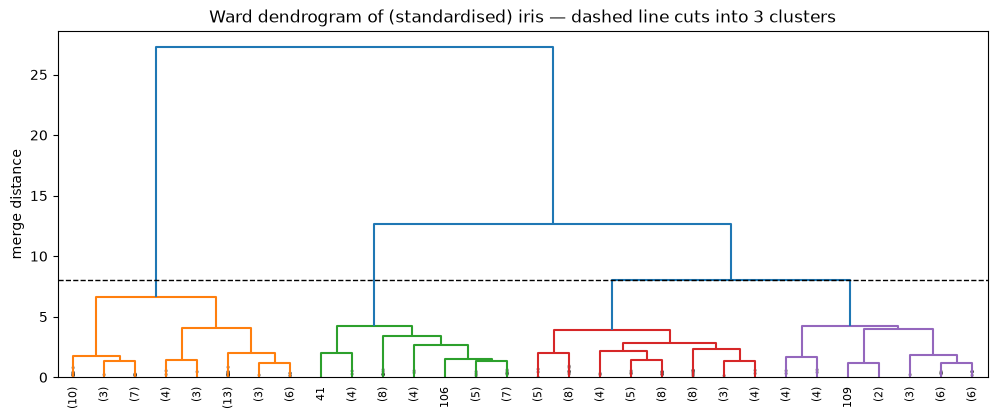

ARI of 3-cluster cut vs species: 0.615


In [13]:
iris = load_iris()
Xi = StandardScaler().fit_transform(iris.data)
Zw = linkage(Xi, method="ward")

fig, ax = plt.subplots(figsize=(12, 4.5))
dendrogram(Zw, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8,
           show_contracted=True, color_threshold=Zw[-3, 2] - 1e-9, ax=ax)
ax.axhline(Zw[-3, 2] - 1e-9, color="k", ls="--", lw=1)
ax.set_title("Ward dendrogram of (standardised) iris — dashed line cuts into 3 clusters")
ax.set_ylabel("merge distance"); plt.show()
flat = fcluster(Zw, t=3, criterion="maxclust")
print("ARI of 3-cluster cut vs species:", round(adjusted_rand_score(iris.target, flat), 3))

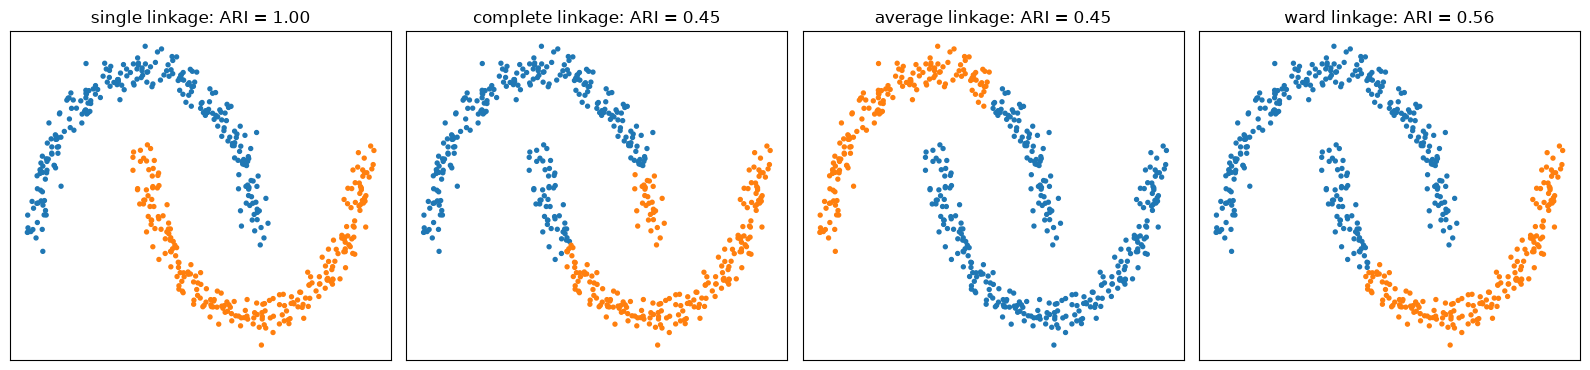

In [14]:
# Linkage matters: moons with single vs. complete vs. average vs. Ward linkage
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, link in zip(axes, ["single", "complete", "average", "ward"]):
    lab = AgglomerativeClustering(n_clusters=2, linkage=link).fit_predict(Xm)
    ax.scatter(Xm[:, 0], Xm[:, 1], c=lab, cmap="tab10", s=8, vmin=0, vmax=9)
    ax.set_title(f"{link} linkage: ARI = {adjusted_rand_score(ym, lab):.2f}"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Single linkage follows the moon shapes (it is essentially connected components of a thresholded MST), but it is fragile: a few noise points bridging the moons would chain them together.

## 9. DBSCAN

**DBSCAN** (Ester et al., 1996) defines clusters as dense regions. With parameters $\varepsilon$ and `min_samples` $=m$:

- a **core point** has at least $m$ points (including itself) within distance $\varepsilon$;
- a point is **density-reachable** from a core point if there is a chain of core points, each within $\varepsilon$ of the next, ending within $\varepsilon$ of it;
- a **cluster** is a maximal set of density-connected points; points reachable from no core point are **noise** (label $-1$).

Advantages: arbitrary cluster shapes, automatic number of clusters, explicit outlier detection. Drawbacks: a single global density threshold (struggles when clusters have different densities — HDBSCAN addresses this), sensitivity to $\varepsilon$, and distance concentration in high dimensions. With a spatial index, cost is about $O(n\log n)$.

**Choosing $\varepsilon$ — the $k$-distance plot:** sort all points by the distance to their $m$-th nearest neighbour and look for the "knee": points above it are in sparse regions.

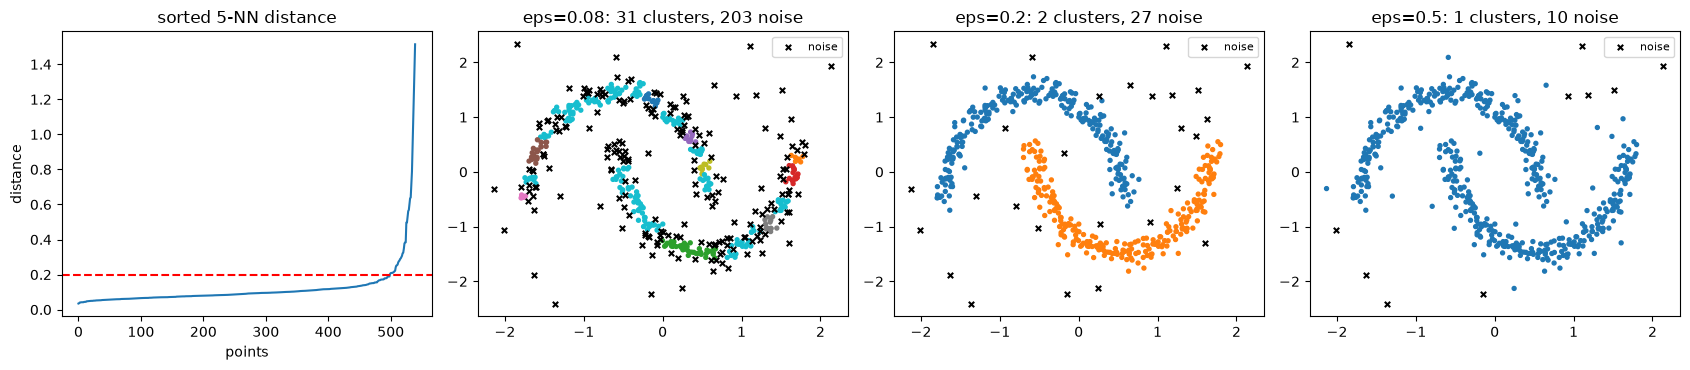

In [15]:
Xn = np.r_[Xm, rng.uniform([-1.5, -1], [2.5, 1.5], size=(40, 2))]   # moons + uniform outliers
Xn_s = StandardScaler().fit_transform(Xn)
min_samples = 5
dist, _ = NearestNeighbors(n_neighbors=min_samples).fit(Xn_s).kneighbors(Xn_s)
kdist = np.sort(dist[:, -1])

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
axes[0].plot(kdist); axes[0].axhline(0.2, color="r", ls="--")
axes[0].set_title(f"sorted {min_samples}-NN distance"); axes[0].set_xlabel("points"); axes[0].set_ylabel("distance")
for ax, eps in zip(axes[1:], [0.08, 0.2, 0.5]):
    lab = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xn_s)
    noise = lab == -1
    ax.scatter(Xn_s[~noise, 0], Xn_s[~noise, 1], c=lab[~noise], cmap="tab10", s=8, vmin=0, vmax=9)
    ax.scatter(Xn_s[noise, 0], Xn_s[noise, 1], c="k", marker="x", s=15, label="noise")
    ax.set_title(f"eps={eps}: {lab.max() + 1} clusters, {noise.sum()} noise"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10. Evaluating clusterings; clustering handwritten digits

**External indices** (require reference labels; invariant to label permutation):

- **Adjusted Rand Index (ARI):** the Rand index counts pairs of points on which two partitions agree (both together or both apart). ARI corrects it for chance: $\mathrm{ARI}=\frac{\mathrm{RI}-\mathbb E[\mathrm{RI}]}{\max\mathrm{RI}-\mathbb E[\mathrm{RI}]}$, so random labelings score $\approx0$ and identical partitions score $1$.
- **Normalised Mutual Information (NMI):** $\mathrm{NMI}(U,V)=\frac{I(U;V)}{\operatorname{mean}(H(U),H(V))}\in[0,1]$. (Not chance-corrected; AMI is the adjusted version.)

**Internal indices** (no labels): silhouette, Davies–Bouldin, Calinski–Harabasz. They encode assumptions (e.g. convexity) and favour algorithms sharing those assumptions — DBSCAN on moons may have a *worse* silhouette than $k$-means despite being "right".

We now cluster the 1797 $8\times8$ digit images ($d=64$) with several algorithms and compare to the true digit labels (which the algorithms never see).

In [16]:
digits = load_digits()
Xdg = StandardScaler().fit_transform(digits.data)
Xdg_pca = PCA(n_components=30, random_state=0).fit_transform(Xdg)   # PCA (Lecture 09) as denoising preprocessing
ydg = digits.target

algos = {
    "k-means (k=10)": lambda Z: KMeans(10, n_init=10, random_state=0).fit_predict(Z),
    "GMM diag (k=10)": lambda Z: GaussianMixture(10, covariance_type="diag", n_init=3, random_state=0).fit(Z).predict(Z),
    "Agglomerative Ward": lambda Z: AgglomerativeClustering(10, linkage="ward").fit_predict(Z),
    "Agglomerative single": lambda Z: AgglomerativeClustering(10, linkage="single").fit_predict(Z),
    "DBSCAN (eps=4.5)": lambda Z: DBSCAN(eps=4.5, min_samples=5).fit_predict(Z),
}
rows, preds = [], {}
for name, f in algos.items():
    lab = f(Xdg_pca); preds[name] = lab
    rows.append({"algorithm": name, "#clusters": len(set(lab) - {-1}), "noise frac": np.mean(lab == -1),
                 "ARI": adjusted_rand_score(ydg, lab), "NMI": normalized_mutual_info_score(ydg, lab),
                 "silhouette": silhouette_score(Xdg_pca, lab)})
pd.DataFrame(rows).set_index("algorithm").round(3)

,#clusters,noise frac,ARI,NMI,silhouette
algorithm,,,,,
k-means (k=10),10,0.000,0.553,0.693,0.178
GMM diag (k=10),10,0.000,0.478,0.623,0.148
Agglomerative Ward,10,0.000,0.666,0.792,0.150
Agglomerative single,10,0.000,0.000,0.011,0.532
DBSCAN (eps=4.5),3,0.069,0.001,0.044,0.190


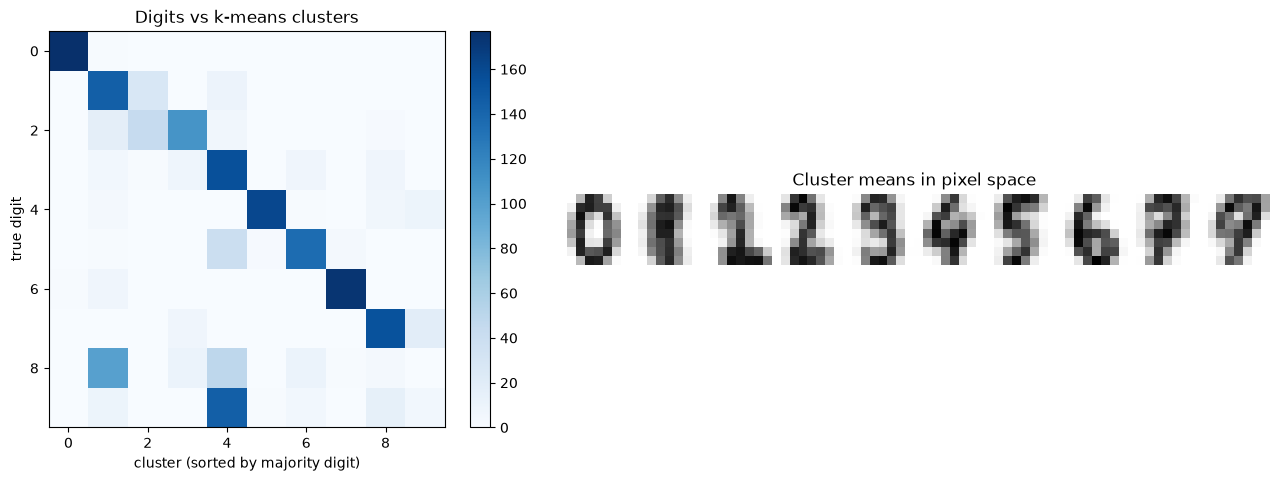

In [17]:
# Which digits get confused? Match each k-means cluster to its majority digit
lab = preds["k-means (k=10)"]
cm = confusion_matrix(ydg, lab)
order = np.argmax(cm, axis=0).argsort()                   # reorder clusters by majority digit
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})
im = axes[0].imshow(cm[:, order], cmap="Blues"); axes[0].set_xlabel("cluster (sorted by majority digit)")
axes[0].set_ylabel("true digit"); axes[0].set_title("Digits vs k-means clusters"); plt.colorbar(im, ax=axes[0])
# cluster centroids back in pixel space
centroids = np.array([digits.data[lab == j].mean(0) for j in order])
axes[1].imshow(np.hstack([c.reshape(8, 8) for c in centroids]), cmap="gray_r")
axes[1].set_title("Cluster means in pixel space"); axes[1].axis("off")
plt.tight_layout(); plt.show()

$k$-means and Ward recover most digits (the centroids look like prototypical digits), but merge or split visually similar classes such as 1/8/9. Single linkage collapses almost everything into one giant cluster (chaining), and DBSCAN with one global $\varepsilon$ likewise merges most digits into a single dense component: in 30 dimensions, density contrasts are weak.

Note the **silhouette column**: the useless single-linkage solution has by far the *highest* silhouette (one huge cluster plus a few far-away singletons). Internal indices can be badly misleading. High-dimensional clustering benefits greatly from good representations (Lecture 09).

## 11. Pitfalls & practical tips

- **Scale features** before any distance-based method; the result depends on the metric.
- **Run $k$-means with several restarts** (`n_init`) and $k$-means++; report the best inertia. For large $n$, `MiniBatchKMeans`.
- **Do not trust a single criterion for $k$.** Combine elbow, silhouette, BIC, stability under resampling, and domain knowledge — and accept that the "right" $k$ may not exist.
- **Match the algorithm to the cluster shape**: $k$-means/Ward for compact blobs, GMM for ellipsoids and soft assignments, DBSCAN/HDBSCAN/single linkage for arbitrary shapes and noise, spectral clustering for manifold-like structure.
- **GMM degeneracies**: components can collapse onto single points; use `reg_covar`, restrict the covariance type, or use a Bayesian GMM (`BayesianGaussianMixture`) with priors.
- **High dimensions**: distances concentrate; reduce dimension first (PCA) and consider cosine distance for text-like data.
- **Evaluation**: external indices need labels you usually do not have; internal indices are biased toward certain shapes. Always visualise (e.g. on a 2-D embedding) and inspect cluster prototypes.
- **Clusters are not classes**: the digit labels are one of many valid groupings (writing style and stroke thickness are others).

## 12. Exercises

**Exercise 1 (pen & paper — $k$-means).** (a) Prove that for a fixed assignment the cluster mean minimises $\sum_{i\in C}\lVert\mathbf x_i-\boldsymbol\mu\rVert^2$, and that this equals $\frac1{2|C|}\sum_{i,i'\in C}\lVert\mathbf x_i-\mathbf x_{i'}\rVert^2$. (b) Show Lloyd's algorithm terminates in finitely many iterations. (c) Give a 1-D example with 4 points and $k=2$ where Lloyd converges to a non-optimal fixed point.

**Exercise 2 (pen & paper — EM).** (a) Derive the M-step for $\pi_j$ using a Lagrange multiplier. (b) Derive EM updates for a GMM with *shared spherical* covariance $\sigma^2I$. (c) Show that as $\sigma\to0$ the responsibilities become hard nearest-centre assignments.

**Exercise 3 (pen & paper — BIC).** Count the free parameters of a $k$-component GMM in $d$ dimensions for the four covariance types (`full`, `tied`, `diag`, `spherical`). For $d=64$ (digits) and $k=10$, compare the counts with $n=1797$ and comment.

**Exercise 4 (coding — $k$-medoids).** Implement the alternating $k$-medoids algorithm (assign to nearest medoid; within each cluster, choose the point minimising the sum of distances to the others). Compare to $k$-means on blobs contaminated with a few far outliers.

**Exercise 5 (coding — DBSCAN from scratch).** Implement DBSCAN with a precomputed distance matrix (BFS expansion from core points). Verify your labels against `sklearn.cluster.DBSCAN` using ARI (border points may be assigned differently — why?).

**Exercise 6 (coding — spectral clustering).** Build an RBF affinity matrix on the moons data, form the normalised Laplacian $L=I-D^{-1/2}WD^{-1/2}$, take the eigenvectors of the 2 smallest eigenvalues, normalise rows and run $k$-means on them. Compare with `SpectralClustering`.

In [18]:
# Exercise 4 — TODO: k-medoids (alternating algorithm)
def kmedoids(X, k, max_iter=100, seed=0):
    # Return (medoid_indices, labels)
    rng_ = np.random.default_rng(seed)
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(-1))   # pairwise distances
    medoids = rng_.choice(len(X), k, replace=False)
    # TODO: alternate assignment and medoid update until medoids stop changing
    return None

In [19]:
# Exercise 5 — TODO: DBSCAN from scratch
def dbscan_scratch(X, eps, min_samples):
    # Return integer labels with -1 for noise
    labels = np.full(len(X), -1)
    # TODO: compute neighbourhoods, identify core points, expand clusters by BFS
    pass

## 13. Summary

- **$k$-means** minimises within-cluster squared distances; **Lloyd's algorithm** alternates nearest-centroid assignment and mean updates, converging monotonically to a local optimum. **$k$-means++** seeding gives an $O(\log k)$ approximation guarantee and much better runs.
- Choose $k$ with the **elbow**, **silhouette**, gap statistic or **BIC** — none is definitive.
- $k$-means assumes convex, isotropic, similar-size clusters; it fails on moons, anisotropic and unequal-variance data.
- **GMMs** give soft, ellipsoidal clusters. **EM** maximises a lower bound: E-step = responsibilities, M-step = weighted MLEs; $k$-means is its hard, isotropic limit.
- **Hierarchical clustering** yields a dendrogram; the linkage defines the notion of cluster (single = chaining, Ward = compact).
- **DBSCAN** finds arbitrarily shaped dense clusters and labels noise, but needs a good $\varepsilon$ and struggles with varying densities and high dimensions.
- Evaluate with **ARI/NMI** when labels exist, **silhouette** otherwise — and remember each criterion carries assumptions.

## Further reading

- ESL (Hastie, Tibshirani & Friedman), Ch. 14.3 (cluster analysis), 8.5 (EM).
- ISLR/ISLP (James et al.), Ch. 12.4.
- Bishop PRML, Ch. 9 (mixture models and EM).
- Murphy PML, Ch. 21 (clustering) and Ch. 8.7 (EM).
- Géron, *Hands-On Machine Learning*, Ch. 9.
- Lloyd, "Least squares quantization in PCM", *IEEE Trans. Inf. Theory*, 1982.
- Arthur & Vassilvitskii, "k-means++: the advantages of careful seeding", SODA 2007.
- Dempster, Laird & Rubin, "Maximum likelihood from incomplete data via the EM algorithm", *JRSS-B*, 1977.
- Ester, Kriegel, Sander & Xu, "A density-based algorithm for discovering clusters (DBSCAN)", KDD 1996.
- Hubert & Arabie, "Comparing partitions", *J. Classification*, 1985.
- von Luxburg, "A tutorial on spectral clustering", *Statistics and Computing*, 2007.
- Kleinberg, "An impossibility theorem for clustering", NeurIPS 2002.